In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cascade.agents.db_orm import TrajectoryDB, DBTrajectoryFrame, DBTrainingFrame, DBControllerLog

In [2]:
db_url = 'postgresql://ase:pw@localhost:5432/cascade'
db = TrajectoryDB(db_url)
run_id = '2026.09.03-22:03:35-e79143'
target_ferr = 1.4  # this run's --target-ferr; not persisted in the DB

In [3]:
def load_traj_data(db, run_id, traj_id):
    attempts = pd.DataFrame.from_records(db.list_trajectory_attempts(run_id, traj_id))

    with db.session() as sess:
        frame_rows = sess.query(DBTrajectoryFrame).filter_by(run_id=run_id, traj_id=traj_id).order_by(
            DBTrajectoryFrame.chunk_id, DBTrajectoryFrame.attempt_index, DBTrajectoryFrame.frame_index
        ).all()
        uq_records = []
        frame_id_to_index = {}
        for row in frame_rows:
            atoms = db._deserialize_atoms(row.atoms_blob)
            uq_records.append({
                'chunk_id': row.chunk_id,
                'attempt_index': row.attempt_index,
                'frame_index': row.frame_index,
                'uq': atoms.info.get('uq_force_std_max'),
            })
            frame_id_to_index[row.id] = (row.chunk_id, row.attempt_index, row.frame_index)
        uq_df = pd.DataFrame(uq_records)

        train_rows = sess.query(DBTrainingFrame).filter_by(run_id=run_id, traj_id=traj_id).all()
        error_records = []
        for row in train_rows:
            loc = frame_id_to_index.get(row.trajectory_frame_id)
            if loc is None:
                continue
            chunk_id, attempt_index, frame_index = loc
            error_records.append({
                'chunk_id': chunk_id,
                'attempt_index': attempt_index,
                'frame_index': frame_index,
                'calibration_uq': row.calibration_uq,
                'calibration_error': row.calibration_error,
            })
        error_df = pd.DataFrame(error_records)

        log_rows = sess.query(DBControllerLog).filter(
            DBControllerLog.run_id == run_id,
            (DBControllerLog.traj_id == traj_id) | (DBControllerLog.traj_id.is_(None)),
        ).order_by(DBControllerLog.created_at).all()
        threshold_log = pd.DataFrame.from_records([
            {'created_at': r.created_at, 'threshold': r.threshold} for r in log_rows
        ])

    return attempts, uq_df, error_df, threshold_log

In [4]:
def threshold_at(threshold_log, when):
    if threshold_log.empty:
        return np.nan
    prior = threshold_log[threshold_log['created_at'] <= when]
    if prior.empty:
        return np.nan
    return prior.iloc[-1]['threshold']

In [5]:
def plot_traj(traj_id, attempts, uq_df, error_df, threshold_log, target_ferr):
    n = len(attempts)
    fig, axes = plt.subplots(n, 1, figsize=(9, 2.2 * n), squeeze=False)
    axes = axes[:, 0]
    first_ax_uq, first_ax_err = None, None

    for row, (ax_uq, (_, attempt)) in enumerate(zip(axes, attempts.iterrows())):
        ax_err = ax_uq.twinx()
        if row == 0:
            first_ax_uq, first_ax_err = ax_uq, ax_err

        chunk_id, attempt_index = attempt['chunk_id'], attempt['attempt_index']
        uq_sub = uq_df[(uq_df['chunk_id'] == chunk_id) & (uq_df['attempt_index'] == attempt_index)]
        err_sub = error_df[(error_df['chunk_id'] == chunk_id) & (error_df['attempt_index'] == attempt_index)]
        thr = threshold_at(threshold_log, attempt['updated_at'])

        ax_uq.plot(uq_sub['frame_index'], uq_sub['uq'], color='tab:blue', label='UQ', zorder=2)
        if np.isfinite(thr):
            ax_uq.axhline(thr, color='tab:blue', linestyle='--', linewidth=1, label='UQ threshold', zorder=1)
        if not err_sub.empty:
            ax_err.scatter(err_sub['frame_index'], err_sub['calibration_error'], color='tab:red',
                           marker='x', label='observed error', zorder=3)
        ax_err.axhline(target_ferr, color='tab:red', linestyle='--', linewidth=1, label='error target', zorder=1)

        ax_uq.set_yscale('log')
        ax_err.set_yscale('log')
        ax_uq.tick_params(axis='y', labelcolor='tab:blue', labelsize=8)
        ax_err.tick_params(axis='y', labelcolor='tab:red', labelsize=8)
        ax_uq.tick_params(axis='x', labelsize=8)
        ax_uq.set_title(
            f"chunk {chunk_id} attempt {attempt_index} (model_v {attempt['model_version']}) "
            f"— {attempt['audit_status']} ({attempt['audit_reason']})",
            fontsize=9,
        )

    handles, labels = first_ax_uq.get_legend_handles_labels()
    h2, l2 = first_ax_err.get_legend_handles_labels()
    first_ax_uq.legend(handles + h2, labels + l2, fontsize=8, loc='upper right')

    axes[-1].set_xlabel('frame index')
    fig.suptitle(f'Traj {traj_id}: UQ (left, blue) / observed error (right, red) per attempt', y=1.0)
    fig.tight_layout()
    plt.show()

In [6]:
traj_data = {traj_id: load_traj_data(db, run_id, traj_id) for traj_id in [0, 1, 2]}
passed_error_data = {traj_id: pd.DataFrame(db.get_reference_evaluations(run_id, traj_id)) for traj_id in [0, 1, 2]}

In [7]:
def plot_error_histogram(traj_id, error_df, passed_df, target_ferr):
    fig, (ax_rej, ax_acc) = plt.subplots(1, 2, figsize=(11, 3), sharey=False)

    ax_rej.hist(error_df['calibration_error'], bins=30, color='tab:red', alpha=0.7)
    ax_rej.axvline(target_ferr, color='black', linestyle='--', linewidth=1, label='error target')
    ax_rej.set_xlabel('observed error (calibration_error)')
    ax_rej.set_ylabel('count')
    ax_rej.set_title(f'Traj {traj_id}: rejected chunks')
    ax_rej.legend(fontsize=8)

    ax_acc.hist(passed_df['force_error'], bins=30, color='tab:green', alpha=0.7)
    ax_acc.axvline(target_ferr, color='black', linestyle='--', linewidth=1, label='error target')
    ax_acc.set_xlabel('observed error (force_error)')
    ax_acc.set_title(f'Traj {traj_id}: accepted chunks')
    ax_acc.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

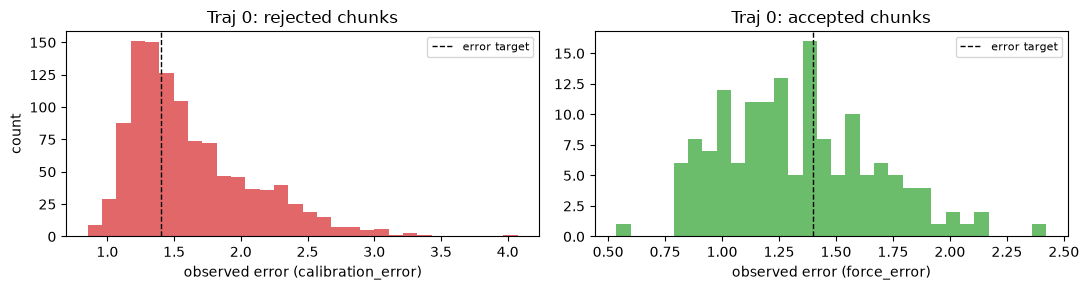

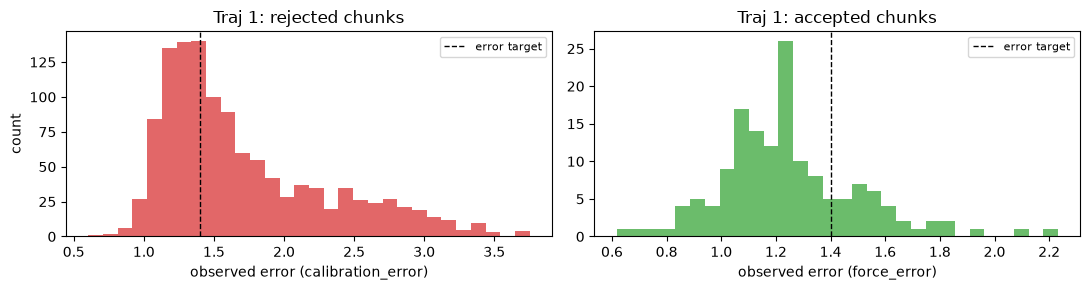

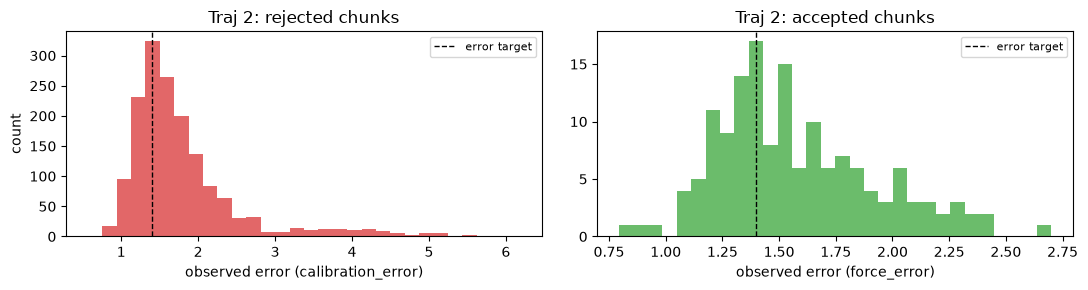

In [8]:
for traj_id, (attempts, uq_df, error_df, threshold_log) in traj_data.items():
    plot_error_histogram(traj_id, error_df, passed_error_data[traj_id], target_ferr)

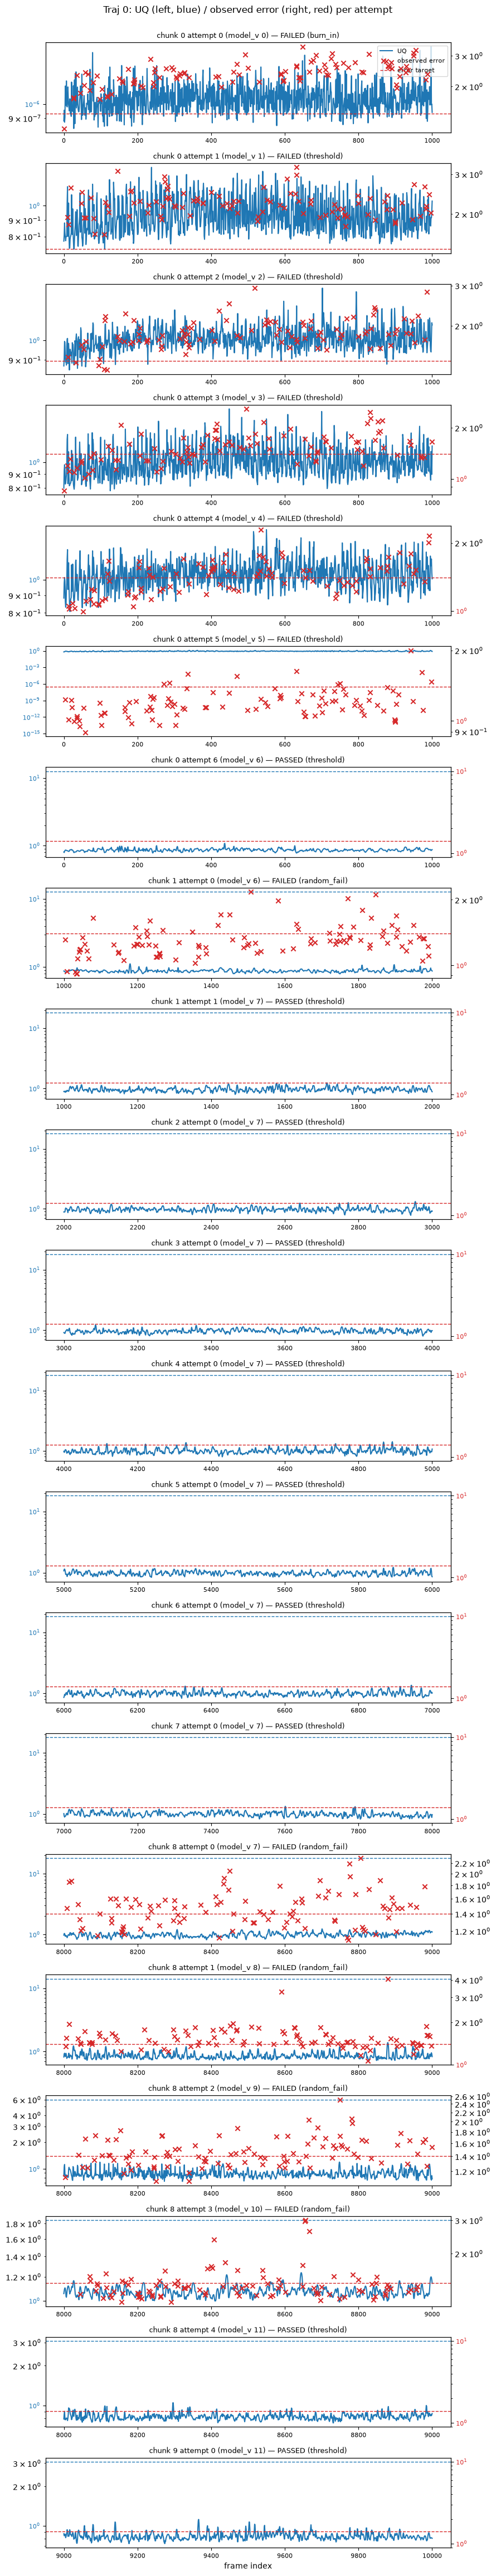

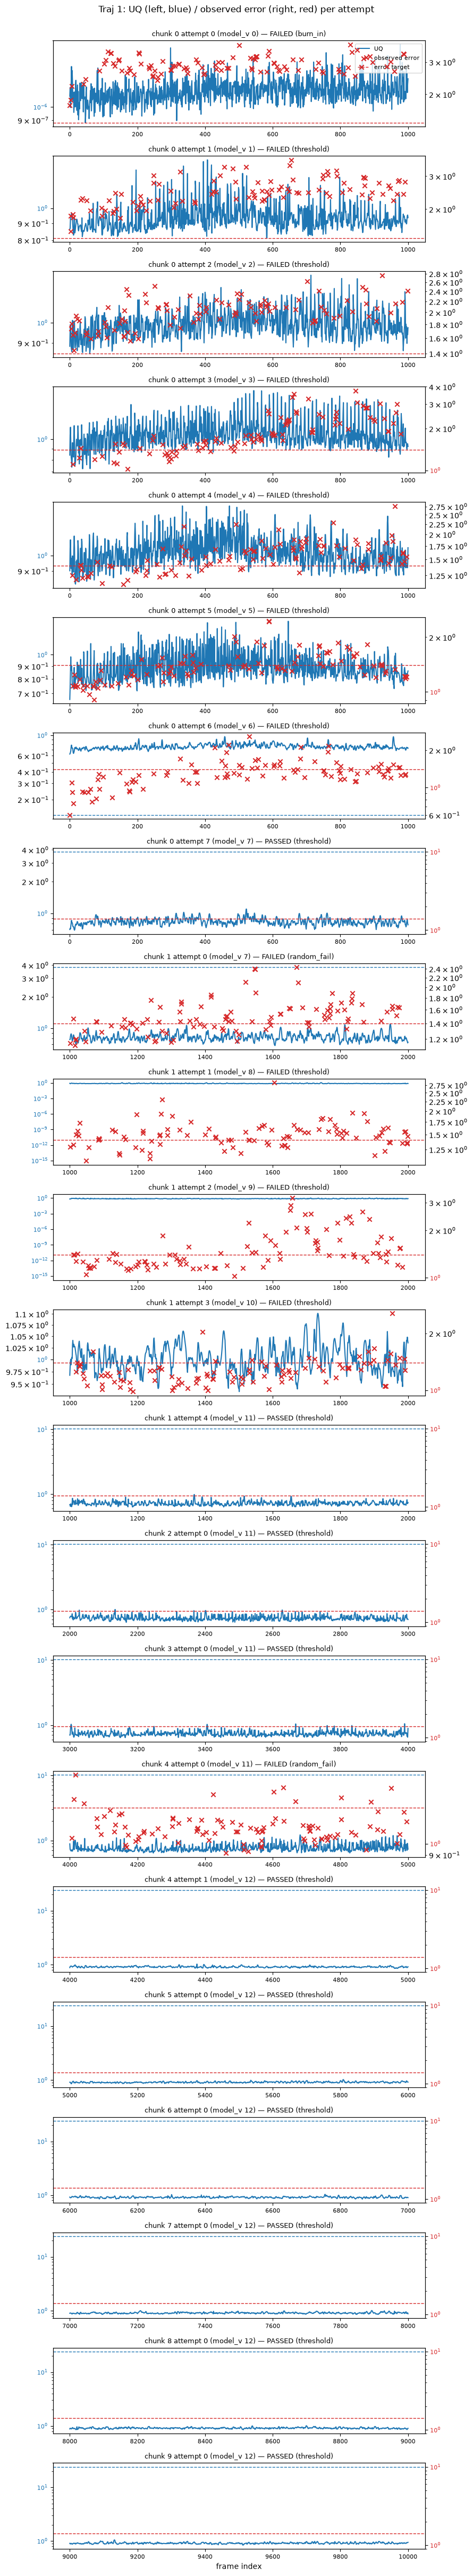

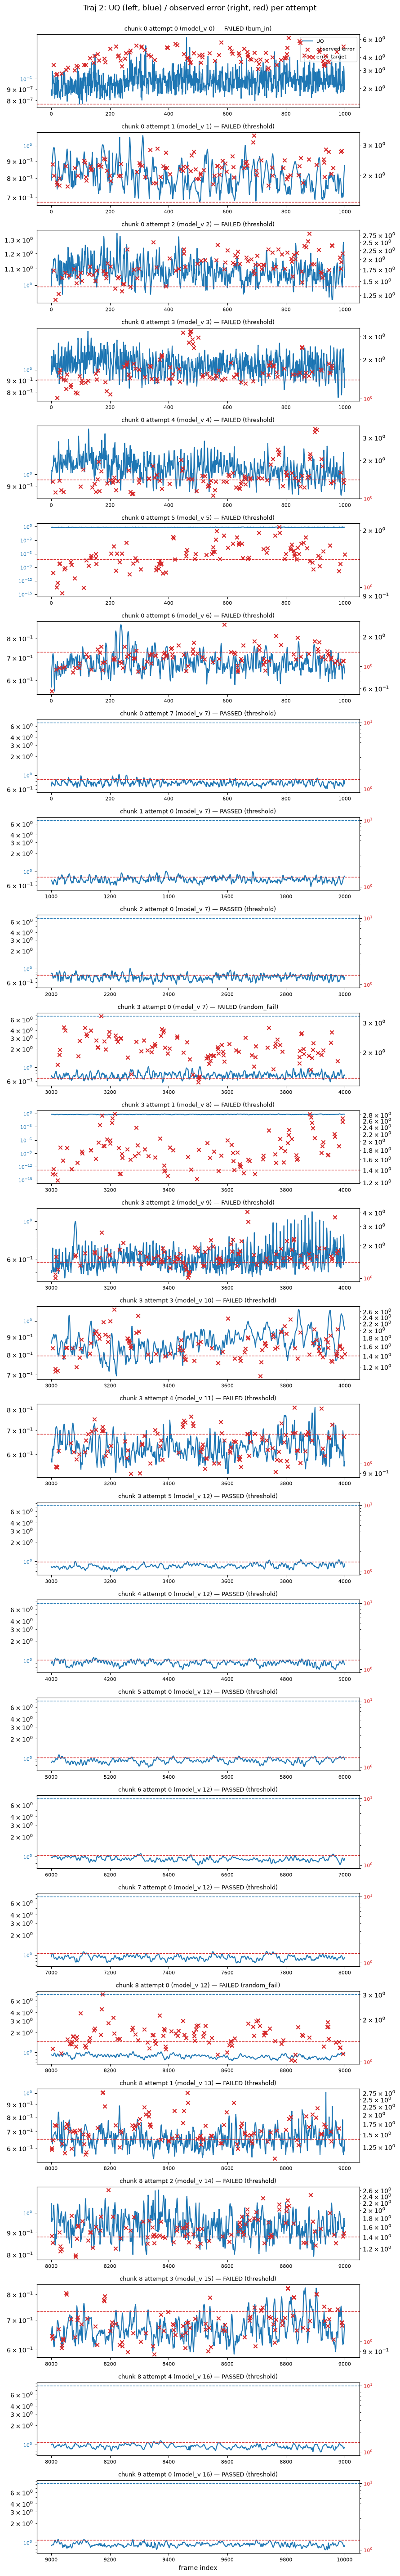

In [9]:
for traj_id, (attempts, uq_df, error_df, threshold_log) in traj_data.items():
    plot_traj(traj_id, attempts, uq_df, error_df, threshold_log, target_ferr)

In [10]:
def plot_traj_summary(traj_id, attempts, uq_df, error_df, threshold_log, target_ferr):
    attempts = attempts.reset_index(drop=True).copy()
    attempts['x'] = range(len(attempts))

    avg_uq = uq_df.groupby(['chunk_id', 'attempt_index'])['uq'].mean().rename('avg_uq')
    avg_error = error_df.groupby(['chunk_id', 'attempt_index'])['calibration_error'].mean().rename('avg_error')
    attempts = attempts.set_index(['chunk_id', 'attempt_index'])
    attempts['avg_uq'] = avg_uq
    attempts['avg_error'] = avg_error
    attempts = attempts.reset_index()
    attempts['threshold'] = [threshold_at(threshold_log, u) for u in attempts['updated_at']]

    fig, ax_uq = plt.subplots(figsize=(12, 4))
    ax_err = ax_uq.twinx()

    ax_uq.plot(attempts['x'], attempts['avg_uq'], color='tab:blue', marker='o', label='avg UQ', zorder=2)
    ax_uq.plot(attempts['x'], attempts['threshold'], color='tab:blue', linestyle='--', label='UQ threshold', zorder=1)
    ax_err.scatter(attempts['x'], attempts['avg_error'], color='tab:red', marker='x', label='avg observed error', zorder=3)
    ax_err.axhline(target_ferr, color='tab:red', linestyle='--', linewidth=1, label='error target', zorder=1)

    # symlog only on the UQ axis, since its threshold genuinely hits exactly 0 and plain
    # log can't show that; the error axis never approaches 0 so plain log stays correct there.
    # Clip to [0, 100] rather than letting symlog mirror equal space onto the negative side,
    # since UQ is never negative -- there's nothing to show there.
    ax_uq.set_yscale('symlog', linthresh=1e-6)
    ax_uq.set_ylim(0, 100)
    ax_err.set_yscale('log')
    ax_uq.tick_params(axis='y', which='both', color='tab:blue', labelcolor='tab:blue')
    ax_err.tick_params(axis='y', which='both', color='tab:red', labelcolor='tab:red')

    boundaries = attempts.groupby('chunk_id')['x'].min().values
    for b in boundaries[1:]:
        ax_uq.axvline(b - 0.5, color='gray', linestyle=':', alpha=0.5, zorder=0)

    ax_uq.set_xticks(attempts['x'])
    ax_uq.set_xticklabels(
        [f"c{c}a{a}" for c, a in zip(attempts['chunk_id'], attempts['attempt_index'])],
        rotation=90, fontsize=7,
    )
    ax_uq.set_xlabel('chunk / attempt')
    ax_uq.set_ylabel('avg UQ', color='tab:blue')
    ax_err.set_ylabel('avg observed error', color='tab:red')

    h1, l1 = ax_uq.get_legend_handles_labels()
    h2, l2 = ax_err.get_legend_handles_labels()
    ax_uq.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')

    fig.suptitle(f'Traj {traj_id}: per-attempt average UQ / error / threshold', y=1.05)
    fig.tight_layout()
    plt.show()

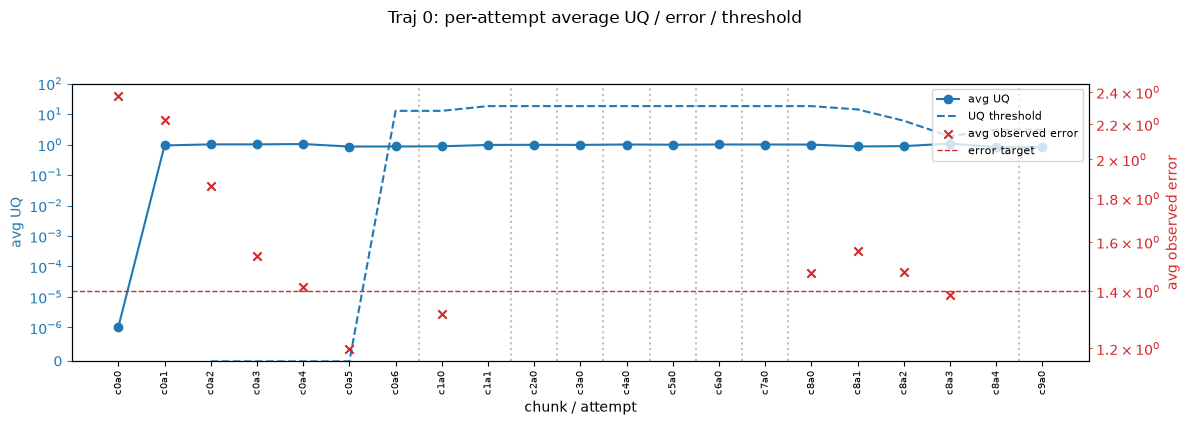

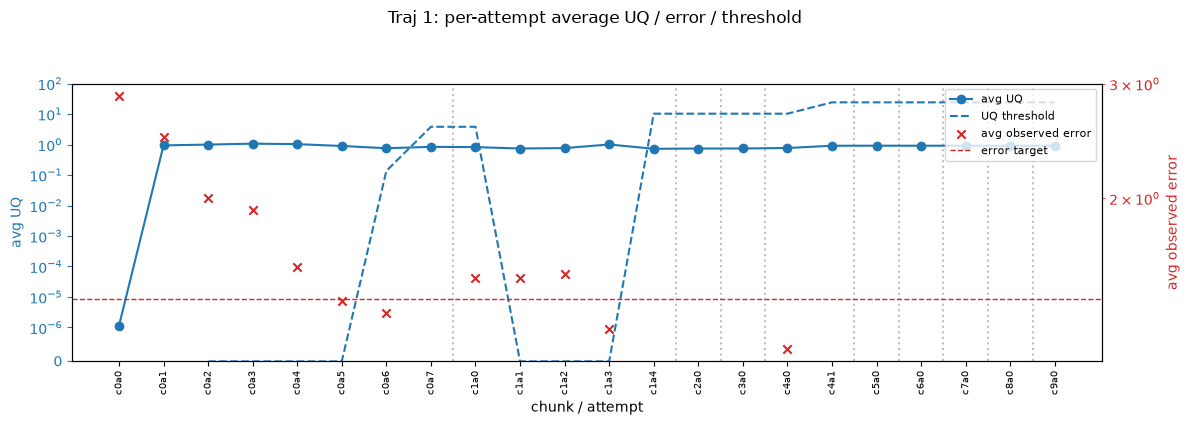

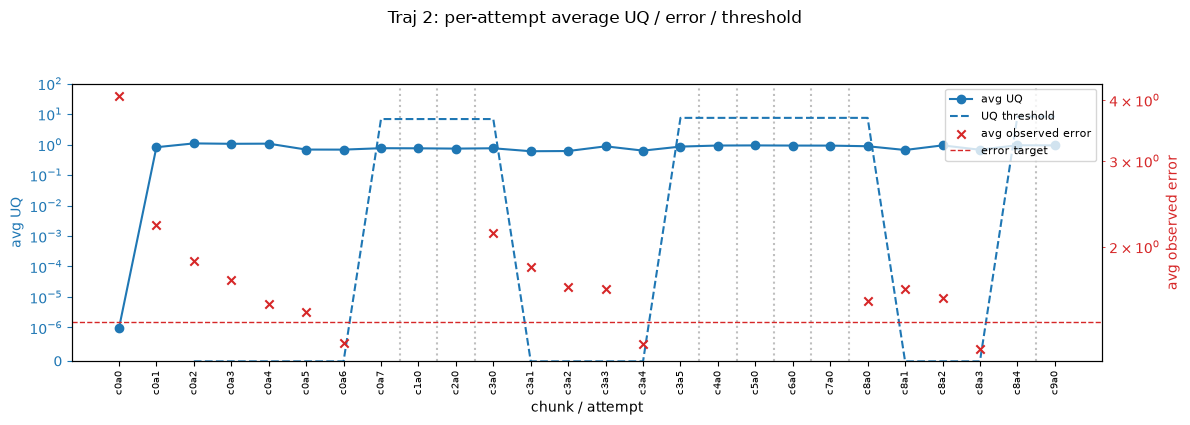

In [11]:
for traj_id, (attempts, uq_df, error_df, threshold_log) in traj_data.items():
    plot_traj_summary(traj_id, attempts, uq_df, error_df, threshold_log, target_ferr)

In [55]:
from matplotlib.ticker import FuncFormatter

def sci_tick(x, pos):
    if x == 0:
        return '0'
    mantissa, exp = f'{x:.0e}'.split('e')
    return f'{mantissa}e{int(exp)}'

def plot_traj_summary_manuscript(traj_id, attempts, uq_df, error_df, threshold_log, target_ferr,
                                 save_path=None, ylim=(0, 100)):
    attempts = attempts.reset_index(drop=True).copy()
    attempts['x'] = range(len(attempts))

    avg_uq = uq_df.groupby(['chunk_id', 'attempt_index'])['uq'].mean().rename('avg_uq')
    max_uq = uq_df.groupby(['chunk_id', 'attempt_index'])['uq'].max().rename('max_uq')
    avg_error = error_df.groupby(['chunk_id', 'attempt_index'])['calibration_error'].mean().rename('avg_error')
    max_error = error_df.groupby(['chunk_id', 'attempt_index'])['calibration_error'].max().rename('max_error')
    attempts = attempts.set_index(['chunk_id', 'attempt_index'])
    attempts['avg_uq'] = avg_uq
    attempts['max_uq'] = max_uq
    attempts['avg_error'] = avg_error
    attempts['max_error'] = max_error
    attempts = attempts.reset_index()
    attempts['threshold'] = [threshold_at(threshold_log, u) for u in attempts['updated_at']]

    fig, ax_uq = plt.subplots(figsize=(7, 4.326/2), dpi=300)
    ax_err = ax_uq.twinx()

    ax_uq.plot(attempts['x'], attempts['max_uq'], color='tab:blue', marker='o', markersize=4,
              linewidth=1.2, label='max UQ', zorder=2)
    # ax_uq.plot(attempts['x'], attempts['max_uq'], color='steelblue', marker='^', markersize=4,
    #           linewidth=1.2, linestyle=':', label='max UQ', zorder=2)
    ax_uq.plot(attempts['x'], attempts['threshold'], color='tab:blue', linestyle='--',
              linewidth=1.2, label='UQ threshold', zorder=1)
    ax_err.scatter(attempts['x'], attempts['avg_error'], color='tab:red', marker='x', s=25,
                   label='avg observed error', zorder=3)
    # ax_err.scatter(attempts['x'], attempts['max_error'], color='darkred', marker='+', s=35,
    #                label='max observed error', zorder=3)
    ax_err.axhline(target_ferr, color='tab:red', linestyle='--', linewidth=1.2, label='error target', zorder=1)

    #ax_uq.set_yscale('symlog', linthresh=1e-6)
    ax_uq.set_ylim(*ylim)
    #ax_err.set_yscale('log')
    #ax_uq.yaxis.set_major_formatter(FuncFormatter(sci_tick))
    #ax_err.yaxis.set_major_formatter(FuncFormatter(sci_tick))
    ax_uq.tick_params(axis='y', which='both', color='tab:blue', labelcolor='tab:blue', labelsize=9)
    ax_err.tick_params(axis='y', which='both', color='tab:red', labelcolor='tab:red', labelsize=9)

    boundaries = attempts.groupby('chunk_id')['x'].min().values
    for b in boundaries[1:]:
        ax_uq.axvline(b - 0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5, zorder=0)

    ax_uq.set_xticks(attempts['x'])
    ax_uq.set_xticklabels(
        [f"s{c}a{a}" for c, a in zip(attempts['chunk_id'], attempts['attempt_index'])],
        rotation=90, fontsize=6.5,
    )
    ax_uq.set_xlabel('Segment / Attempt', fontsize=10)
    ax_uq.set_ylabel('Uncertainty', color='tab:blue', fontsize=10)
    ax_err.set_ylabel('Force Error', color='tab:red', fontsize=10)

    h1, l1 = ax_uq.get_legend_handles_labels()
    h2, l2 = ax_err.get_legend_handles_labels()
    ax_uq.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper right', framealpha=0.9)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()

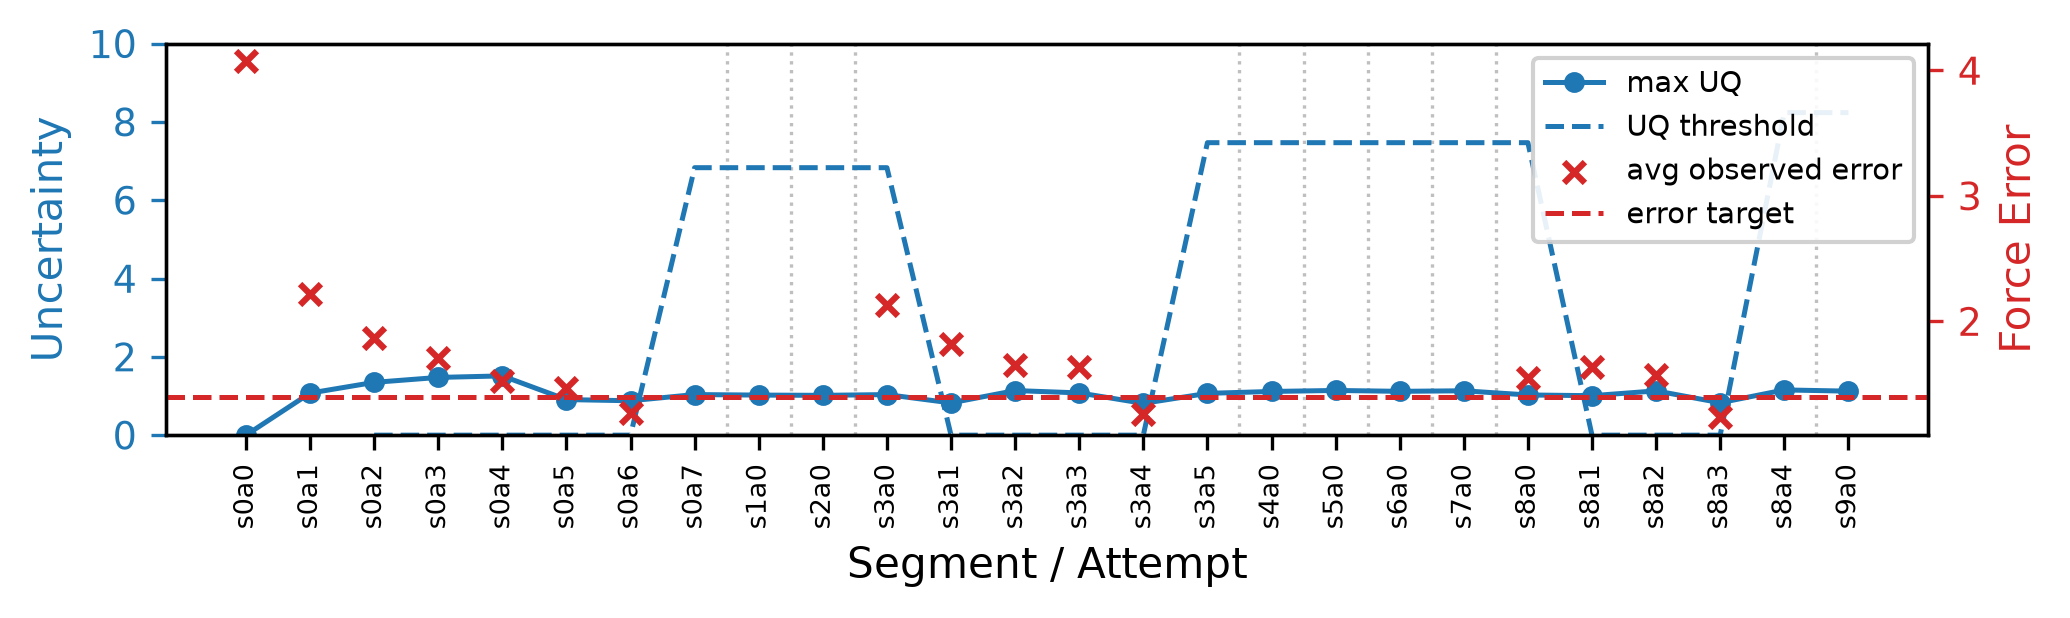

In [57]:
attempts, uq_df, error_df, threshold_log = traj_data[2]
plot_traj_summary_manuscript(2, attempts, uq_df, error_df, threshold_log, target_ferr,
                             save_path='traj2_uq_error_threshold_summary.pdf', ylim=(0, 10))

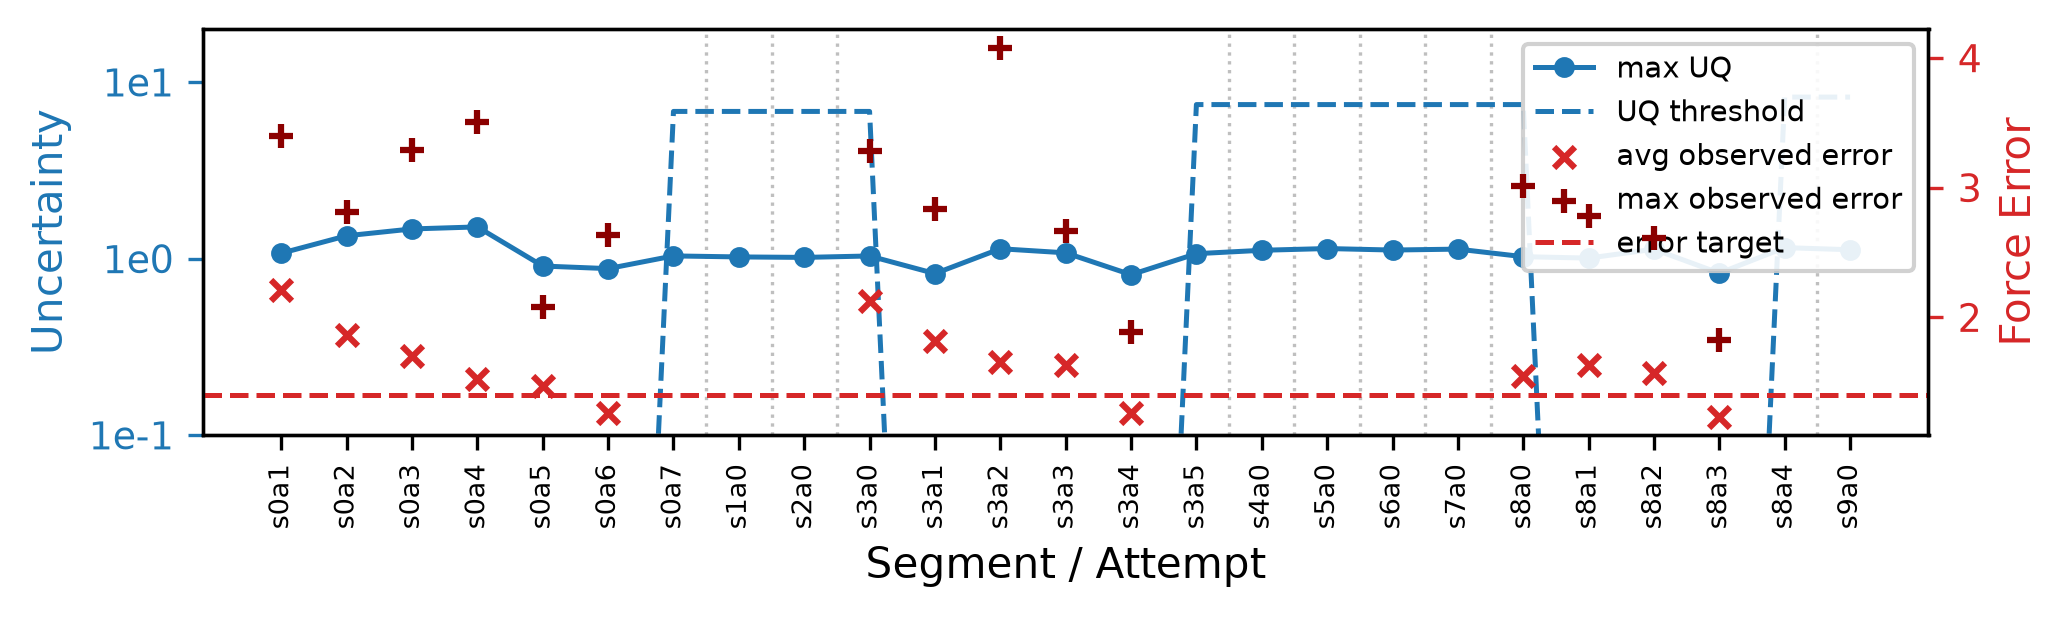

In [47]:
# Second version: drop the very first attempt (s0a0, the burn_in attempt on stock/identical
# clones) -- its UQ is pinned near 0 and its error a huge outlier, which compresses the
# y-range enough to hide the real variance among all the other attempts. Also tighten ylim
# from (0, 100) to (0, 20) -- max threshold excluding s0a0 is ~8.24, so 20 keeps it fully
# visible with headroom while giving much more room to the 0.6-1.2 UQ cluster than 100 did.
attempts, uq_df, error_df, threshold_log = traj_data[2]
attempts_trimmed = attempts.iloc[1:]
plot_traj_summary_manuscript(2, attempts_trimmed, uq_df, error_df, threshold_log, target_ferr,
                             save_path='traj2_uq_error_threshold_summary_no_s0a0.pdf', ylim=(1e-1, 20))